In [1]:
import numpy as np
from scipy import optimize
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

import os, sys
sys.path.append(os.path.abspath('../../Software/'))
import rate_methods_library as RM
import ks_censored as ksc

In [2]:
barrs = [5,7,9,11,13]
beta = 1. / (312.*0.008314)
true = 1.4328652141523972e-6
k_low = 0.2219796815459443 + np.log(1e-6)
k_high = 0.46802748239726666 + np.log(1e-6)
runs = [f"run_{i+1}" for i in range(100)]

In [3]:
k0s_Q = {}
v_datas_Q = {}
avg_ebv_Q = []
avg_ebv_t_Q = {}

gammas = np.linspace(0,1,21)

ts_barrs = []
ix_col_barrs_Q = []
ys_barrs = []
emp_rates_Q = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}

def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_Q[barr] = []
    
    colvars = glob(f"../../Data/protG/Q_frac_native_contacts_opes/qruns_barr{barr}/run_*/opes_short.colvar")
    log_files = glob(f"../../Data/protG/Q_frac_native_contacts_opes/qruns_barr{barr}/run_*/p.log")
    data = RM.get_data(colvars,0,3,time_scale_factor=1e-6)
    num_runs = len(data)
    colvars_numbers = np.array([colvar.split('/')[-2] for colvar in colvars])
    logs_numbers = np.array([log_file.split('/')[-2] for log_file in log_files])
    
    runs = [f"{i+1}" for i in range(num_runs)]

    # Handle transitions
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    final_times = np.array([traj[-1][0] for traj in data])
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]+np.float64(barr)))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_row_counts = np.sort([len(traj[:,0]) for traj in data])
    max_index = colvar_row_counts[-1]
    min_index = 0
    v_data = np.full((len(data), max_index-min_index), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:(min(len(traj),max_index)-min_index)] = traj[min_index:max_index,1]+np.float64(barr)
    v_datas_Q[barr] = v_data
    
    ecdfxs[barr] = np.sort(final_times)[:transitioned.sum()] # This is only valid if all transitions occur before all non-transitioned simulations ended.
    ecdfys[barr] = np.linspace(1/num_runs,1,num_runs)[:transitioned.sum()]
    emp_rate = optimize.curve_fit(poisson_CDF,ecdfxs[barr],ecdfys[barr],p0=1e-6)[0][0]
    emp_rates_Q[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')
    
    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    #ecdfxs[barr] = t
    #ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_Q[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln<e^βV>: {np.log(avg)}')
    avg_ebv_Q.append(np.log(avg))
    
    print('')
    
    for gamma in gammas:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=0))
        k0s_Q[barr].append(np.log(emp_rate)-np.log(avg))

100 out of 100 simulations transitioned.
avg. max. bias: 6.43154128
tau_obs: 0.14059709918656416, k_obs: 7.11252227667271, log k_obs: 1.9618569314929166
Modified KS stat: 0.8356933735064911; p = 0.48730603624954427
ln<e^βV>: 2.027268595353286

100 out of 100 simulations transitioned.
avg. max. bias: 8.91442606
tau_obs: 0.07532536094106418, k_obs: 13.275741231195914, log k_obs: 2.585938402194124
Modified KS stat: 1.2523575175173276; p = 0.08683605228400382
ln<e^βV>: 2.7320928220980503

100 out of 100 simulations transitioned.
avg. max. bias: 10.924816200000002
tau_obs: 0.039557132783022995, k_obs: 25.279890872909192, log k_obs: 3.2300092525331525
Modified KS stat: 1.1355192652342103; p = 0.15166251126903596
ln<e^βV>: 3.3729543897085117

100 out of 100 simulations transitioned.
avg. max. bias: 13.015902270000002
tau_obs: 0.031091487511040572, k_obs: 32.163144321895196, log k_obs: 3.470821210734682
Modified KS stat: 1.4424623501040958; p = 0.031171474898436413
ln<e^βV>: 3.9166768522354483

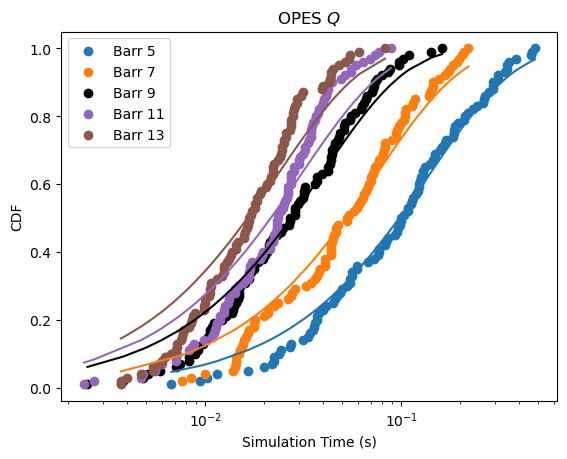

In [4]:
plt.xscale('log')

colors = ['C0','C1','k','C4','C5','C6','C7','C8','C9','C10']

for i, barr in enumerate(barrs):
    plt.plot(ecdfxs[barr],poisson_CDF(ecdfxs[barr],emp_rates_Q[barr]),color=colors[i])
    plt.scatter(ecdfxs[barr],ecdfys[barr],label=f'Barr {barr}',color=colors[i])

plt.title(r'OPES $Q$')
plt.xlabel('Simulation Time (s)')
plt.ylabel('CDF')
plt.legend()

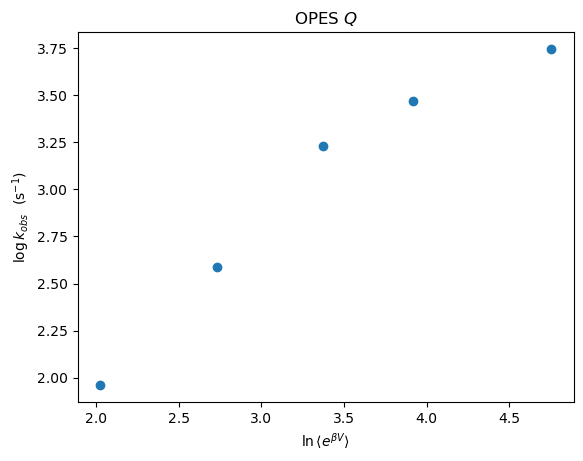

In [5]:
plt.title(r'OPES $Q$')
plt.xlabel(r'$\ln \langle e^{\beta V} \rangle$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{s}^{-1})$')
plt.scatter(avg_ebv_Q[:6],[k0s_Q[barr][0] for barr in barrs[:6]])

In [6]:
avgs_Q = [np.mean([k0s_Q[barr][i] for barr in barrs]) for i in range(len(gammas))]
vars_Q = [np.var([k0s_Q[barr][i] for barr in barrs]) for i in range(len(gammas))]

In [7]:
def variance(gamma):
    k0s = []
    for barr in barrs[:6]:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_datas_Q[barr]),axis=0))
        k0s.append(np.log(emp_rates_Q[barr])-np.log(avg))
    return np.var(k0s)

gamma_best_Q = optimize.minimize_scalar(variance,bounds=(0.,1.)).x
k0s = []
for barr in barrs:
    avg = np.mean(np.nanmean(np.exp(beta*gamma_best_Q*v_datas_Q[barr]),axis=0))
    k0s.append(np.log(emp_rates_Q[barr])-np.log(avg))
k0_best_Q = np.mean(k0s)
print(f'LEAST VAR:  gamma: {gamma_best_Q}, lnk0: {k0_best_Q} (ms^-1), k0: {np.exp(k0_best_Q)} ms^-1, τ0: {np.exp(-k0_best_Q)} ms')

LEAST VAR:  gamma: 0.7157174551073776, lnk0: 0.6815249154036037 (ms^-1), k0: 1.9768900249512174 ms^-1, τ0: 0.5058450330461233 ms


In [8]:
k0s_E = {}
v_datas_E = {}
avg_ebv_E = []
avg_ebv_t_E = {}

gammas = np.linspace(0,1,21)

ts_barrs = []
ix_col_barrs_E = []
ys_barrs = []
emp_rates_E = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}

def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_E[barr] = []
    
    colvars = glob(f"../../Data/protG/E_end_end_distance_opes/eruns_barr{barr}/run_*/opes_short.colvar")
    log_files = glob(f"../../Data/protG/E_end_end_distance_opes/eruns_barr{barr}/run_*/p.log")
    data = RM.get_data(colvars,0,4,time_scale_factor=1e-6)
    num_runs = len(data)
    colvars_numbers = np.array([colvar.split('/')[-2] for colvar in colvars])
    logs_numbers = np.array([log_file.split('/')[-2] for log_file in log_files])
    
    runs = [f"{i+1}" for i in range(num_runs)]

    # Handle transitions
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    final_times = np.array([traj[-1][0] for traj in data])
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]+np.float64(barr)))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_row_counts = np.sort([len(traj[:,0]) for traj in data])
    max_index = colvar_row_counts[-1]
    min_index = 0
    v_data = np.full((len(data), max_index-min_index), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:(min(len(traj),max_index)-min_index)] = traj[min_index:max_index,1]+np.float64(barr)
    v_datas_E[barr] = v_data
    
    ecdfxs[barr] = np.sort(final_times)[:transitioned.sum()] # This is only valid if all transitions occur before all non-transitioned simulations ended.
    ecdfys[barr] = np.linspace(1/num_runs,1,num_runs)[:transitioned.sum()]
    emp_rate = optimize.curve_fit(poisson_CDF,ecdfxs[barr],ecdfys[barr],p0=1e-6)[0][0]
    emp_rates_E[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')
    
    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    #ecdfxs[barr] = t
    #ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_E[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln<e^βV>: {np.log(avg)}')
    avg_ebv_E.append(np.log(avg))
    
    print('')
    
    for gamma in gammas:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=0))
        k0s_E[barr].append(np.log(emp_rate)-np.log(avg))

100 out of 100 simulations transitioned.
avg. max. bias: 7.08884725
tau_obs: 0.30123131472277254, k_obs: 3.319707982287015, log k_obs: 1.1998768219174756
Modified KS stat: 0.8859443608957539; p = 0.4124273318825341
ln<e^βV>: 2.35391064416752

100 out of 100 simulations transitioned.
avg. max. bias: 10.02220849
tau_obs: 0.29240728206457794, k_obs: 3.4198874697626396, log k_obs: 1.2296076469550037
Modified KS stat: 0.4644830537061026; p = 0.9822713217577582
ln<e^βV>: 3.1513155186339534

100 out of 100 simulations transitioned.
avg. max. bias: 12.20260053
tau_obs: 0.15232227577972368, k_obs: 6.565027963776751, log k_obs: 1.8817567672699453
Modified KS stat: 0.6238934915773061; p = 0.8311546261949253
ln<e^βV>: 3.9017437300811295

100 out of 100 simulations transitioned.
avg. max. bias: 14.527247280000001
tau_obs: 0.16037413368484651, k_obs: 6.235419497043795, log k_obs: 1.8302458578701453
Modified KS stat: 0.7424333974626819; p = 0.6399160167514122
ln<e^βV>: 4.564547830304649

100 out of 1

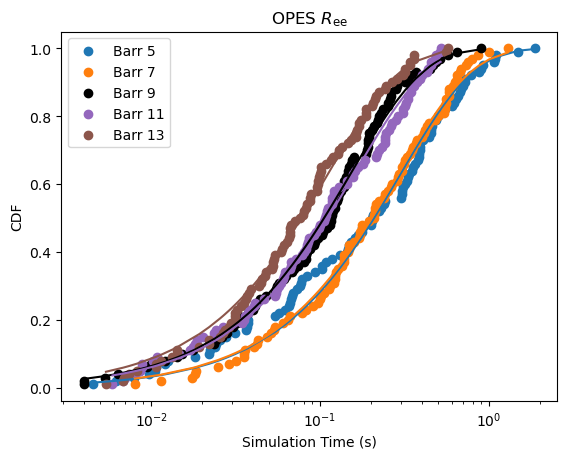

In [9]:
plt.xscale('log')

colors = ['C0','C1','k','C4','C5','C6','C7','C8','C9','C10']

for i, barr in enumerate(barrs):
    plt.plot(ecdfxs[barr],poisson_CDF(ecdfxs[barr],emp_rates_E[barr]),color=colors[i])
    plt.scatter(ecdfxs[barr],ecdfys[barr],label=f'Barr {barr}',color=colors[i])

plt.title(r'OPES $R_\mathrm{ee}$')
plt.xlabel('Simulation Time (s)')
plt.ylabel('CDF')
plt.legend()

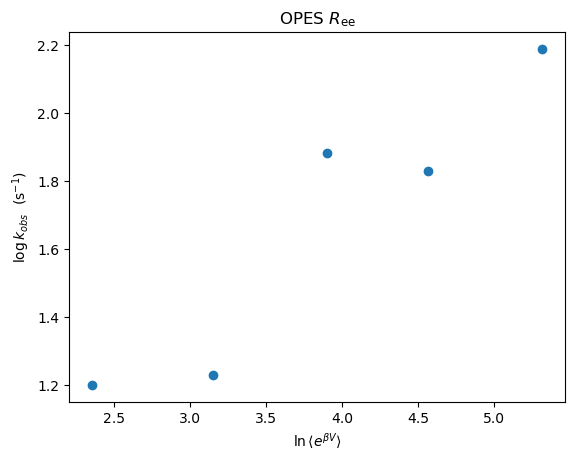

In [10]:
plt.title(r'OPES $R_\mathrm{ee}$')
plt.xlabel(r'$\ln \langle e^{\beta V} \rangle$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{s}^{-1})$')
plt.scatter(avg_ebv_E[:6],[k0s_E[barr][0] for barr in barrs[:6]])

In [11]:
avgs_E = [np.mean([k0s_E[barr][i] for barr in barrs]) for i in range(len(gammas))]
vars_E = [np.var([k0s_E[barr][i] for barr in barrs]) for i in range(len(gammas))]

In [12]:
def variance(gamma):
    k0s = []
    for barr in barrs[:6]:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_datas_E[barr]),axis=0))
        k0s.append(np.log(emp_rates_E[barr])-np.log(avg))
    return np.var(k0s)

gamma_best_E = optimize.minimize_scalar(variance,bounds=(0.,1.)).x
k0s = []
for barr in barrs:
    avg = np.mean(np.nanmean(np.exp(beta*gamma_best_E*v_datas_E[barr]),axis=0))
    k0s.append(np.log(emp_rates_E[barr])-np.log(avg))
k0_best_E = np.mean(k0s)
print(f'LEAST VAR:  gamma: {gamma_best_E}, lnk0: {k0_best_E} (ms^-1), k0: {np.exp(k0_best_E)} ms^-1, τ0: {np.exp(-k0_best_E)} ms')

LEAST VAR:  gamma: 0.41427698164630095, lnk0: 0.21388685365420318 (ms^-1), k0: 1.2384825170944251 ms^-1, τ0: 0.8074397387103023 ms


In [13]:
k0s_G = {}
v_datas_G = {}
avg_ebv_G = []
avg_ebv_t_G = {}

gammas = np.linspace(0,1,21)

ts_barrs = []
ix_col_barrs_G = []
ys_barrs = []
emp_rates_G = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}

def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_G[barr] = []
    
    colvars = glob(f"../../Data/protG/G_radius_of_gyration_opes/gruns_barr{barr}/run_*/opes_short.colvar")
    log_files = glob(f"../../Data/protG/G_radius_of_gyration_opes/gruns_barr{barr}/run_*/p.log")
    data = RM.get_data(colvars,0,4,time_scale_factor=1e-6)
    num_runs = len(data)
    colvars_numbers = np.array([colvar.split('/')[-2] for colvar in colvars])
    logs_numbers = np.array([log_file.split('/')[-2] for log_file in log_files])
    
    runs = [f"{i+1}" for i in range(num_runs)]

    # Handle transitions
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    final_times = np.array([traj[-1][0] for traj in data])
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]+np.float64(barr)))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_row_counts = np.sort([len(traj[:,0]) for traj in data])
    max_index = colvar_row_counts[-1]
    min_index = 0
    v_data = np.full((len(data), max_index-min_index), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:(min(len(traj),max_index)-min_index)] = traj[min_index:max_index,1]+np.float64(barr)
    v_datas_G[barr] = v_data
    
    ecdfxs[barr] = np.sort(final_times)[:transitioned.sum()] # This is only valid if all transitions occur before all non-transitioned simulations ended.
    ecdfys[barr] = np.linspace(1/num_runs,1,num_runs)[:transitioned.sum()]
    emp_rate = optimize.curve_fit(poisson_CDF,ecdfxs[barr],ecdfys[barr],p0=1e-6)[0][0]
    emp_rates_G[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')
    
    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    #ecdfxs[barr] = t
    #ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_G[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln<e^βV>: {np.log(avg)}')
    avg_ebv_G.append(np.log(avg))
    
    print('')
    
    for gamma in gammas:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=0))
        k0s_G[barr].append(np.log(emp_rate)-np.log(avg))

100 out of 100 simulations transitioned.
avg. max. bias: 6.240464509999998
tau_obs: 0.15513775295010207, k_obs: 6.445884260819714, log k_obs: 1.8634418280380867
Modified KS stat: 0.6463668952847479; p = 0.7976168389087784
ln<e^βV>: 2.208076312149868

100 out of 100 simulations transitioned.
avg. max. bias: 8.51987725
tau_obs: 0.09019915201428026, k_obs: 11.086578727942817, log k_obs: 2.4057352531298095
Modified KS stat: 0.846378572951798; p = 0.47083734372220154
ln<e^βV>: 2.9793356696159674

100 out of 100 simulations transitioned.
avg. max. bias: 10.597765989999997
tau_obs: 0.05242736349221921, k_obs: 19.074008940930455, log k_obs: 2.9483266199062412
Modified KS stat: 1.3315350032812545; p = 0.05767982968820984
ln<e^βV>: 3.851130868296841

100 out of 100 simulations transitioned.
avg. max. bias: 12.575429459999999
tau_obs: 0.0488278082794984, k_obs: 20.480132843068354, log k_obs: 3.019455286628217
Modified KS stat: 0.9822115771624432; p = 0.2895581178799731
ln<e^βV>: 4.616645907497674

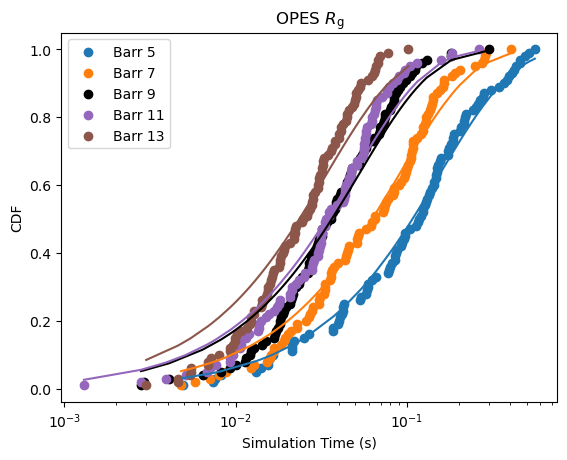

In [14]:
plt.xscale('log')

colors = ['C0','C1','k','C4','C5','C6','C7','C8','C9','C10']

for i, barr in enumerate(barrs):
    plt.plot(ecdfxs[barr],poisson_CDF(ecdfxs[barr],emp_rates_G[barr]),color=colors[i])
    plt.scatter(ecdfxs[barr],ecdfys[barr],label=f'Barr {barr}',color=colors[i])

plt.title(r'OPES $R_\mathrm{g}$')
plt.xlabel('Simulation Time (s)')
plt.ylabel('CDF')
plt.legend()

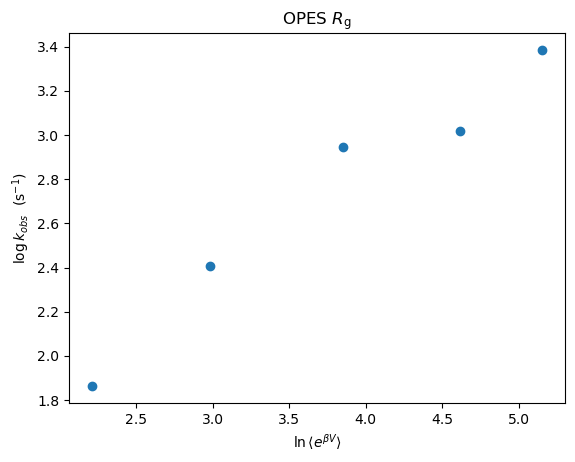

In [15]:
plt.title(r'OPES $R_\mathrm{g}$')
plt.xlabel(r'$\ln \langle e^{\beta V} \rangle$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{s}^{-1})$')
plt.scatter(avg_ebv_G[:6],[k0s_G[barr][0] for barr in barrs[:6]])

In [16]:
avgs_G = [np.mean([k0s_G[barr][i] for barr in barrs]) for i in range(len(gammas))]
vars_G = [np.var([k0s_G[barr][i] for barr in barrs]) for i in range(len(gammas))]

In [17]:
def variance(gamma):
    k0s = []
    for barr in barrs[:6]:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_datas_G[barr]),axis=0))
        k0s.append(np.log(emp_rates_G[barr])-np.log(avg))
    return np.var(k0s)

gamma_best_G = optimize.minimize_scalar(variance,bounds=(0.,1.)).x
k0s = []
for barr in barrs:
    avg = np.mean(np.nanmean(np.exp(beta*gamma_best_G*v_datas_G[barr]),axis=0))
    k0s.append(np.log(emp_rates_G[barr])-np.log(avg))
k0_best_G = np.mean(k0s)
print(f'LEAST VAR:  gamma: {gamma_best_G}, lnk0: {k0_best_G} (ms^-1), k0: {np.exp(k0_best_G)} ms^-1, τ0: {np.exp(-k0_best_G)} ms')

LEAST VAR:  gamma: 0.5152344937089542, lnk0: 0.8484886475064141 (ms^-1), k0: 2.3361134915712847 ms^-1, τ0: 0.428061394965616 ms


In [18]:
k0s_GE = {}
v_datas_GE = {}
avg_ebv_GE = []
avg_ebv_t_GE = {}

gammas = np.linspace(0,1,21)

ts_barrs = []
ix_col_barrs_GE = []
ys_barrs = []
emp_rates_GE = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}

def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_GE[barr] = []
    
    colvars = glob(f"../../Data/protG/2D_GE_opes/geruns_barr{barr}/run_*/opes_short.colvar")
    log_files = glob(f"../../Data/protG/2D_GE_opes/geruns_barr{barr}/run_*/p.log")
    data = RM.get_data(colvars,0,5,time_scale_factor=1e-6)
    num_runs = len(data)
    colvars_numbers = np.array([colvar.split('/')[-2] for colvar in colvars])
    logs_numbers = np.array([log_file.split('/')[-2] for log_file in log_files])
    
    runs = [f"{i+1}" for i in range(num_runs)]

    # Handle transitions
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    final_times = np.array([traj[-1][0] for traj in data])
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]+np.float64(barr)))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_row_counts = np.sort([len(traj[:,0]) for traj in data])
    max_index = colvar_row_counts[-1]
    min_index = 0
    v_data = np.full((len(data), max_index-min_index), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:(min(len(traj),max_index)-min_index)] = traj[min_index:max_index,1]+np.float64(barr)
    v_datas_GE[barr] = v_data
    
    ecdfxs[barr] = np.sort(final_times)[:transitioned.sum()] # This is only valid if all transitions occur before all non-transitioned simulations ended.
    ecdfys[barr] = np.linspace(1/num_runs,1,num_runs)[:transitioned.sum()]
    emp_rate = optimize.curve_fit(poisson_CDF,ecdfxs[barr],ecdfys[barr],p0=1e-6)[0][0]
    emp_rates_GE[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')
    
    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    #ecdfxs[barr] = t
    #ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_GE[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln<e^βV>: {np.log(avg)}')
    avg_ebv_GE.append(np.log(avg))
    
    print('')
    
    for gamma in gammas:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=0))
        k0s_GE[barr].append(np.log(emp_rate)-np.log(avg))

100 out of 100 simulations transitioned.
avg. max. bias: 7.135725790000001
tau_obs: 0.17301506673797243, k_obs: 5.779843448631432, log k_obs: 1.7543765973056176
Modified KS stat: 0.7036240627584524; p = 0.7051939718604163
ln<e^βV>: 2.232708264538494

100 out of 100 simulations transitioned.
avg. max. bias: 9.802869409999998
tau_obs: 0.11845125703233339, k_obs: 8.442291158860662, log k_obs: 2.133253736088078
Modified KS stat: 0.9900057194837595; p = 0.2808675216501825
ln<e^βV>: 2.8273960559535323

100 out of 100 simulations transitioned.
avg. max. bias: 12.14086982
tau_obs: 0.08551415318386699, k_obs: 11.693970679331466, log k_obs: 2.4590733824244815
Modified KS stat: 1.318266551359275; p = 0.061881386718835585
ln<e^βV>: 3.4512746264551084

100 out of 100 simulations transitioned.
avg. max. bias: 14.17907041
tau_obs: 0.06035266910195721, k_obs: 16.56927547496935, log k_obs: 2.807550105375039
Modified KS stat: 1.1543311417223185; p = 0.13915723069171804
ln<e^βV>: 4.135390000710472

100 o

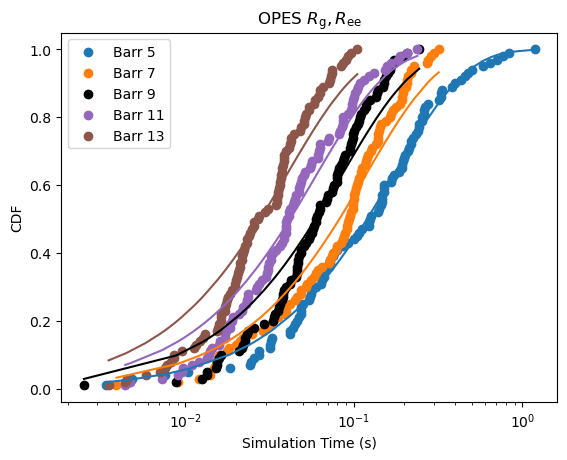

In [19]:
plt.xscale('log')

colors = ['C0','C1','k','C4','C5','C6','C7','C8','C9','C10']

for i, barr in enumerate(barrs):
    plt.plot(ecdfxs[barr],poisson_CDF(ecdfxs[barr],emp_rates_GE[barr]),color=colors[i])
    plt.scatter(ecdfxs[barr],ecdfys[barr],label=f'Barr {barr}',color=colors[i])

plt.title(r'OPES $R_\mathrm{g},R_\mathrm{ee}$')
plt.xlabel('Simulation Time (s)')
plt.ylabel('CDF')
plt.legend()

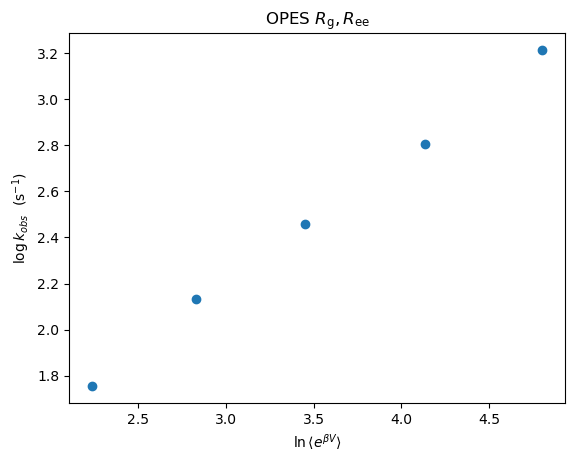

In [20]:
plt.title(r'OPES $R_\mathrm{g},R_\mathrm{ee}$')
plt.xlabel(r'$\ln \langle e^{\beta V} \rangle$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{s}^{-1})$')
plt.scatter(avg_ebv_GE[:6],[k0s_GE[barr][0] for barr in barrs[:6]])

In [21]:
avgs_GE = [np.mean([k0s_GE[barr][i] for barr in barrs]) for i in range(len(gammas))]
vars_GE = [np.var([k0s_GE[barr][i] for barr in barrs]) for i in range(len(gammas))]

In [22]:
def variance(gamma):
    k0s = []
    for barr in barrs[:6]:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_datas_GE[barr]),axis=0))
        k0s.append(np.log(emp_rates_GE[barr])-np.log(avg))
    return np.var(k0s)

gamma_best_GE = optimize.minimize_scalar(variance,bounds=(0.,1.)).x
k0s = []
for barr in barrs:
    avg = np.mean(np.nanmean(np.exp(beta*gamma_best_GE*v_datas_GE[barr]),axis=0))
    k0s.append(np.log(emp_rates_GE[barr])-np.log(avg))
k0_best_GE = np.mean(k0s)
print(f'LEAST VAR:  gamma: {gamma_best_GE}, lnk0: {k0_best_GE} (ms^-1), k0: {np.exp(k0_best_GE)} ms^-1, τ0: {np.exp(-k0_best_GE)} ms')

LEAST VAR:  gamma: 0.6446804737549696, lnk0: 0.39982161661250964 (ms^-1), k0: 1.4915586046321552 ms^-1, τ0: 0.670439630661792 ms


γ Q: 0.7157174551073776, k0 = 1.9768900249512174
γ E: 0.41427698164630095, k0 = 1.2384825170944251
γ G: 0.5152344937089542, k0 = 2.3361134915712847
γ GE: 0.6446804737549696, k0 = 1.4915586046321552


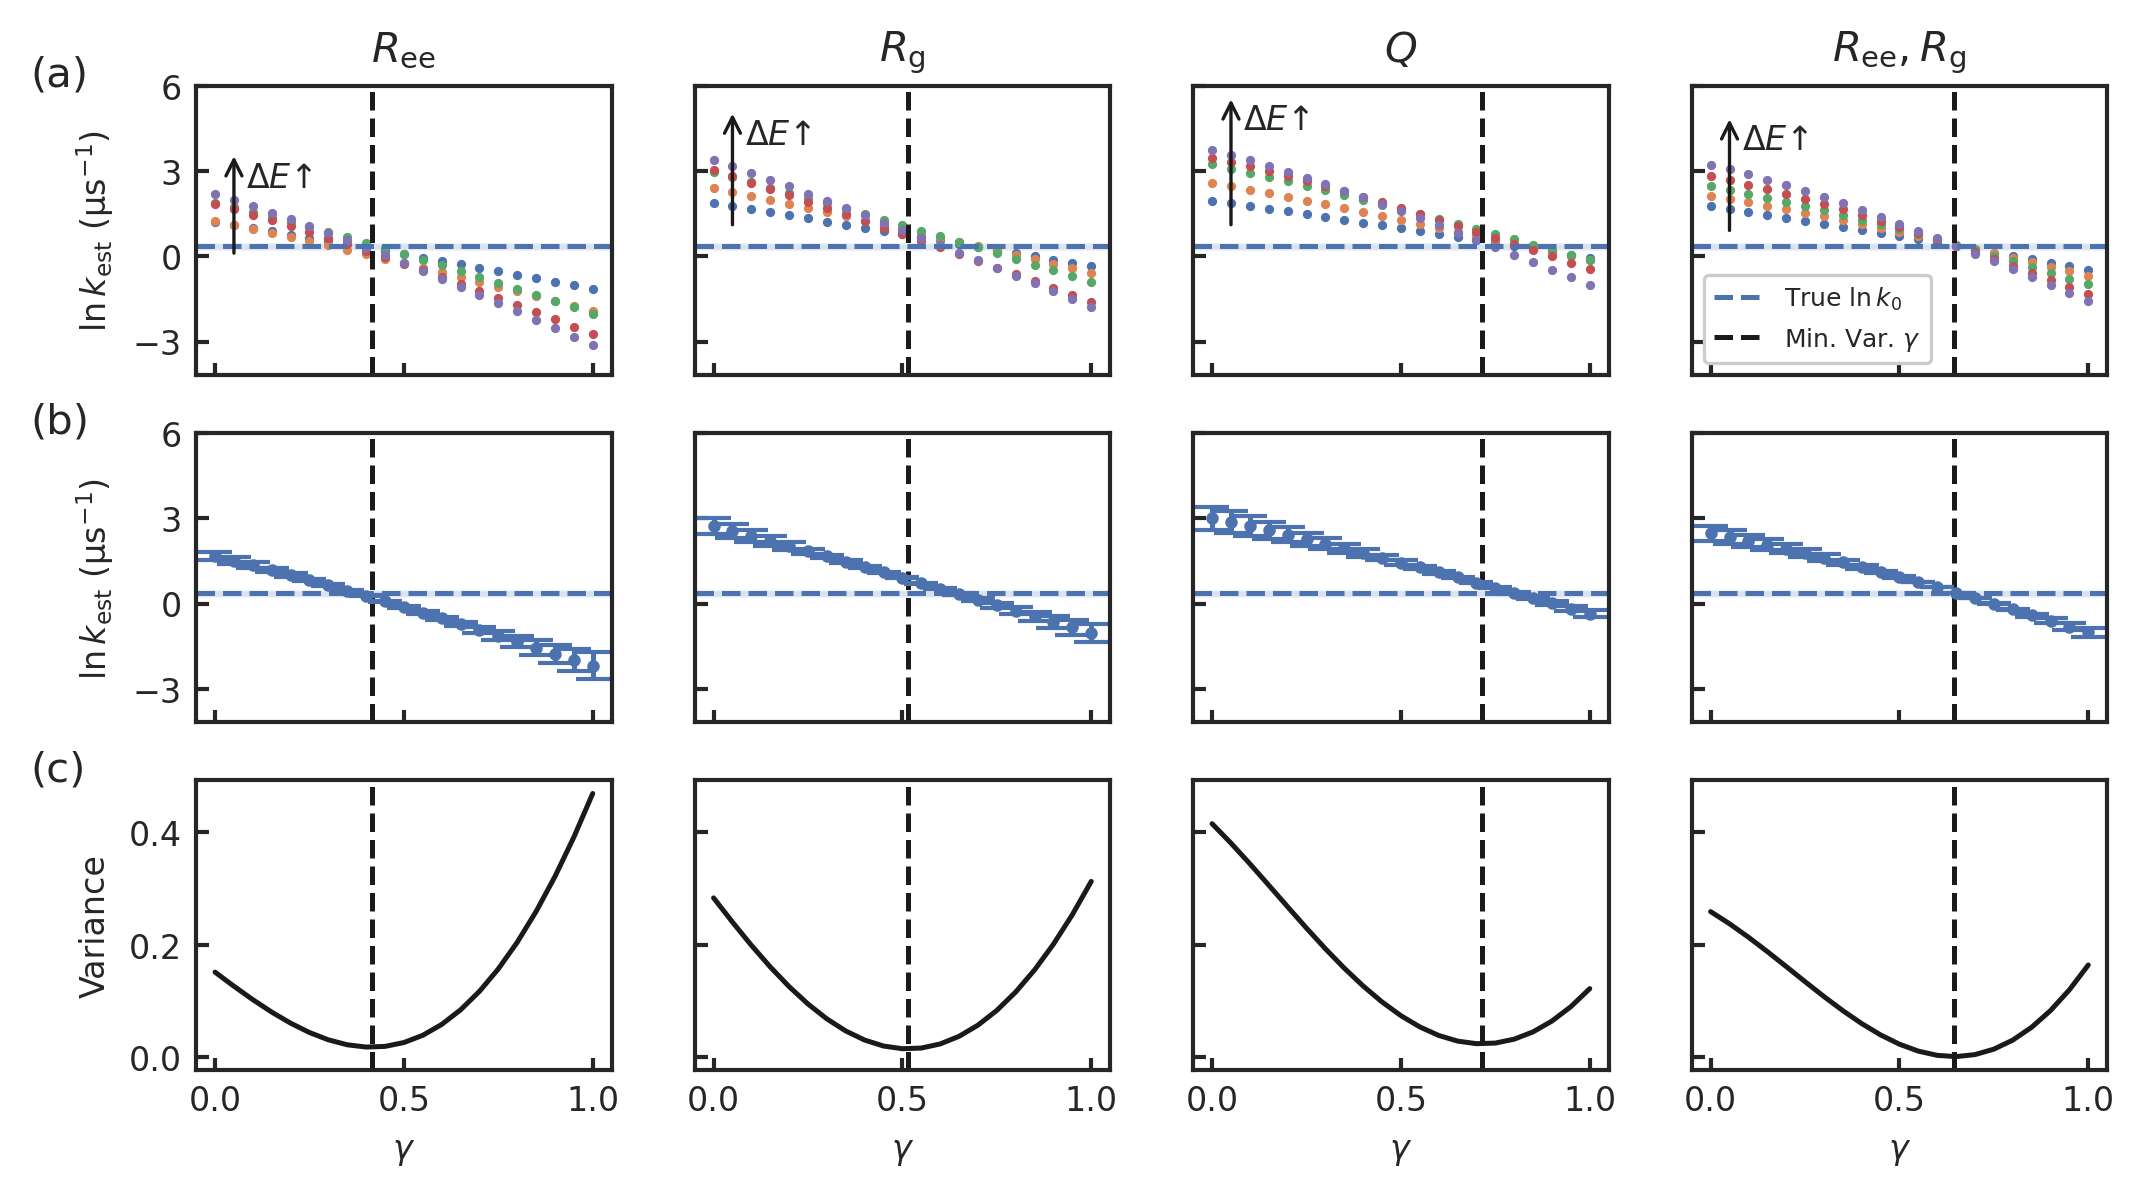

In [23]:
sns.set_theme()
sns.set_style('ticks')
sns.set_context('paper', rc={'axes.labelsize': 8, 'axes.linewidth': 1.0, 'lines.linewidth': 1.2, 'axes.titlesize': 10,
                             'xtick.labelsize': 8, 'ytick.labelsize': 8, 'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
                             'legend.fontsize': 6, 'legend.framealpha': 0, 'lines.markersize': 4})

fig, axs = plt.subplots(3,4,figsize=(7,4),dpi=300,sharey='row',sharex=True)
fig.subplots_adjust(wspace=0.2,bottom=0.1,left=0.08,right=0.99,top=0.92)

true = 1.4328652141523972e-6
k_low = 0.2219796815459443
k_high = 0.46802748239726666

axs[0,0].set_xlim((-0.05,1.05))
axs[0,0].axhline(np.log(true)+np.log(1e6),linestyle='--',color='C0')
axs[0,0].fill_between([-0.05,1.05],k_low,k_high,alpha=0.2)
axs[0,1].axhline(np.log(true)+np.log(1e6),linestyle='--',color='C0')
axs[0,1].fill_between([-0.05,1.05],k_low,k_high,alpha=0.2)
axs[0,2].axhline(np.log(true)+np.log(1e6),linestyle='--',color='C0')
axs[0,2].fill_between([-0.05,1.05],k_low,k_high,alpha=0.2)
axs[0,3].axhline(np.log(true)+np.log(1e6),linestyle='--',color='C0',label=r'True $\ln k_0$')
axs[0,3].fill_between([-0.05,1.05],k_low,k_high,alpha=0.2)
axs[0,2].axvline(gamma_best_Q,linestyle='--',color='k')
axs[1,2].axvline(gamma_best_Q,linestyle='--',color='k')
axs[2,2].axvline(gamma_best_Q,linestyle='--',color='k')
print(f'γ Q: {gamma_best_Q}, k0 = {np.exp(k0_best_Q)}')
axs[0,0].axvline(gamma_best_E,linestyle='--',color='k')
axs[1,0].axvline(gamma_best_E,linestyle='--',color='k')
axs[2,0].axvline(gamma_best_E,linestyle='--',color='k')
print(f'γ E: {gamma_best_E}, k0 = {np.exp(k0_best_E)}')
axs[0,1].axvline(gamma_best_G,linestyle='--',color='k')
axs[1,1].axvline(gamma_best_G,linestyle='--',color='k')
axs[2,1].axvline(gamma_best_G,linestyle='--',color='k')
print(f'γ G: {gamma_best_G}, k0 = {np.exp(k0_best_G)}')
axs[0,3].axvline(gamma_best_GE,linestyle='--',color='k',label=r'Min. Var. $\gamma$')
axs[1,3].axvline(gamma_best_GE,linestyle='--',color='k')
axs[2,3].axvline(gamma_best_GE,linestyle='--',color='k')
print(f'γ GE: {gamma_best_GE}, k0 = {np.exp(k0_best_GE)}')
axs[0,0].set_ylim((-18+np.log(1e6),-8+np.log(1e6)))
#axs[0,0].set_yticks([-9,-12,-15,-18])
axs[0,0].set_yticks([-3,-0,3,6])
axs[1,3].axhline(np.log(true)+np.log(1e6),linestyle='--',color='C0')
axs[1,3].fill_between([-0.05,1.05],k_low,k_high,alpha=0.2)
axs[1,0].axhline(np.log(true)+np.log(1e6),linestyle='--',color='C0')
axs[1,0].fill_between([-0.05,1.05],k_low,k_high,alpha=0.2)
axs[1,1].axhline(np.log(true)+np.log(1e6),linestyle='--',color='C0')
axs[1,1].fill_between([-0.05,1.05],k_low,k_high,alpha=0.2)
axs[1,2].axhline(np.log(true)+np.log(1e6),linestyle='--',color='C0')
axs[1,2].fill_between([-0.05,1.05],k_low,k_high,alpha=0.2)
axs[1,0].set_ylim((-18+np.log(1e6),-8+np.log(1e6)))
#axs[1,0].set_yticks([-9,-12,-15,-18])
axs[1,0].set_yticks([-3,-0,3,6])

for i, barr in enumerate(barrs):
    axs[0,2].scatter(gammas,k0s_Q[barr],color=f'C{i}',s=2,label=f'Barr {barr}')
    axs[0,0].scatter(gammas,k0s_E[barr],color=f'C{i}',s=2,label=f'Barr {barr}')
    axs[0,1].scatter(gammas,k0s_G[barr],color=f'C{i}',s=2,label=f'Barr {barr}')
    axs[0,3].scatter(gammas,k0s_GE[barr],color=f'C{i}',s=2)#,label=f'Barr {barr}')

axs[1,2].errorbar(gammas,avgs_Q,yerr=vars_Q,linestyle='',marker='o',capsize=4,markersize=2)
axs[1,0].errorbar(gammas,avgs_E,yerr=vars_E,linestyle='',marker='o',capsize=4,markersize=2)
axs[1,1].errorbar(gammas,avgs_G,yerr=vars_G,linestyle='',marker='o',capsize=4,markersize=2)
axs[1,3].errorbar(gammas,avgs_GE,yerr=vars_GE,linestyle='',marker='o',capsize=4,markersize=2)
axs[2,2].plot(gammas,vars_Q,color='k')
axs[2,0].plot(gammas,vars_E,color='k')
axs[2,1].plot(gammas,vars_G,color='k')
axs[2,3].plot(gammas,vars_GE,color='k')

axs[0,0].set_ylabel(r'$\ln k_\mathrm{est}~(\mathrm{μs}^{-1})$')
axs[1,0].set_ylabel(r'$\ln k_\mathrm{est}~(\mathrm{μs}^{-1})$')
axs[2,0].set_ylabel('Variance')
axs[2,0].set_xlabel(r'$\gamma$')
axs[2,1].set_xlabel(r'$\gamma$')
axs[2,2].set_xlabel(r'$\gamma$')
axs[2,3].set_xlabel(r'$\gamma$')

axs[0,2].set_title(r'$Q$')
axs[0,0].set_title(r'$R_\mathrm{ee}$')
axs[0,1].set_title(r'$R_\mathrm{g}$')
axs[0,3].set_title(r'$R_\mathrm{ee},R_\mathrm{g}$')
axs[0,3].legend(framealpha=1.0)

axs[0,0].text(-0.4,1.0,"(a)",fontsize=10,transform=axs[0,0].transAxes)
axs[0,2].annotate("",xy=(0.05,-8+np.log(1e6)),xytext=(0.05,-13+np.log(1e6)),arrowprops={'arrowstyle':'->','color':'k'})
axs[0,2].text(0.12,0.85,r"$\Delta E$",fontsize=8,transform=axs[0,2].transAxes)
axs[0,2].text(0.21,0.85,r"$\uparrow$",fontsize=8,transform=axs[0,2].transAxes)
axs[0,0].annotate("",xy=(0.05,-10+np.log(1e6)),xytext=(0.05,-14+np.log(1e6)),arrowprops={'arrowstyle':'->','color':'k'})
axs[0,0].text(0.12,0.65,r"$\Delta E$",fontsize=8,transform=axs[0,0].transAxes)
axs[0,0].text(0.21,0.65,r"$\uparrow$",fontsize=8,transform=axs[0,0].transAxes)
axs[0,1].annotate("",xy=(0.05,-8.5+np.log(1e6)),xytext=(0.05,-13+np.log(1e6)),arrowprops={'arrowstyle':'->','color':'k'})
axs[0,1].text(0.12,0.8,r"$\Delta E$",fontsize=8,transform=axs[0,1].transAxes)
axs[0,1].text(0.21,0.8,r"$\uparrow$",fontsize=8,transform=axs[0,1].transAxes)
axs[0,3].annotate("",xy=(0.05,-8.7+np.log(1e6)),xytext=(0.05,-13.2+np.log(1e6)),arrowprops={'arrowstyle':'->','color':'k'})
axs[0,3].text(0.12,0.78,r"$\Delta E$",fontsize=8,transform=axs[0,3].transAxes)
axs[0,3].text(0.21,0.78,r"$\uparrow$",fontsize=8,transform=axs[0,3].transAxes)
axs[1,0].text(-0.4,1.0,"(b)",fontsize=10,transform=axs[1,0].transAxes)
axs[2,0].text(-0.4,1.0,"(c)",fontsize=10,transform=axs[2,0].transAxes)

for ax in axs.flatten():
    ax.tick_params(axis='both', direction='in', which='both', length=3)

plt.savefig("EATRf_Fig3.pdf",format='pdf')